# 📊 Data Warehouse Spotify
## Analisis Perilaku Pendengar Musik Digital

Notebook ini sudah dirapikan agar **selaras dengan alur ETL** dan struktur notebook temanmu:

1. **Setup & Extract**
2. **Transform**
3. **Build Dimension Tables**
4. **Generate Fact Table**
5. **Load ke SQLite (Data Warehouse)**
6. **Analisis Data (OLAP)**
7. **Dashboard (Visualisasi)**

> **Catatan:** path file disesuaikan untuk folder **`dataset BIawak`** di Google Drive.


## Tujuan Analisis
- Mengintegrasikan data dari beberapa sumber Spotify.
- Membersihkan dan mentransformasi data agar konsisten.
- Membangun **Data Warehouse berbentuk star schema**.
- Menyimpan hasil ETL ke database SQLite **`spotify_dw.db`**.
- Melakukan analisis OLAP untuk menemukan insight bisnis.


# 1. SETUP & EXTRACT


Dataset yang digunakan dalam analisis ini terdiri dari beberapa bagian, yaitu:
1. [Dataset Spotify Tracks](https://www.kaggle.com/datasets/yashdev01/spotify-tracks-dataset) → kakteristik audio lagu
2. [Dataset High Popularity](https://www.kaggle.com/datasets/solomonameh/spotify-music-dataset) → berisi informasi lagu dengan tingkat popularitas
3. [Dataset Churn](https://www.kaggle.com/datasets/nabihazahid/spotify-dataset-for-churn-analysis) → berisi data perilaku pengguna dan status churn

## 1.1 Load Dataset


In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from google.colab import drive
drive.mount('/content/drive')

PATH = "/content/drive/MyDrive/dataset BIawak/"
DB_PATH = os.path.join(PATH, "spotify_dw.db")

tracks_path   = os.path.join(PATH, "spotify_tracks.csv")
playlist_path = os.path.join(PATH, "high_popularity_spotify_data.csv")
users_path    = os.path.join(PATH, "spotify_churn_dataset.csv")

df_tracks   = pd.read_csv(tracks_path)
df_playlist = pd.read_csv(playlist_path)
df_users    = pd.read_csv(users_path)

print("=" * 70)
print("EXTRACT — RAW SHAPE")
print("=" * 70)
print(f"df_tracks   : {df_tracks.shape}")
print(f"df_playlist : {df_playlist.shape}")
print(f"df_users    : {df_users.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EXTRACT — RAW SHAPE
df_tracks   : (6300, 8)
df_playlist : (1686, 29)
df_users    : (8000, 12)


Bagian **Load Dataset (Extract)** ini digunakan untuk mempersiapkan data sebelum masuk ke tahap analisis. Pertama, dilakukan import berbagai library yang dibutuhkan seperti *pandas* dan *numpy* untuk pengolahan data, *sqlite3* untuk koneksi database, serta *matplotlib* dan *seaborn* untuk visualisasi. Selain itu, Google Drive di-*mount* agar notebook dapat mengakses file dataset yang tersimpan secara online.

Selanjutnya, ditentukan path direktori utama yang mengarah ke folder dataset di Google Drive, kemudian dibuat path khusus untuk masing-masing file, yaitu data *tracks*, *playlist*, dan *users*. Ketiga dataset tersebut kemudian dibaca menggunakan fungsi `read_csv()` dan disimpan ke dalam DataFrame terpisah, yaitu `df_tracks`, `df_playlist`, dan `df_users`.

Sebagai langkah validasi awal, ditampilkan ukuran (shape) dari masing-masing dataset untuk memastikan bahwa data berhasil dimuat dengan benar. Hasilnya menunjukkan bahwa dataset *tracks* memiliki 6300 baris dan 8 kolom, *playlist* memiliki 1686 baris dan 29 kolom, serta *users* memiliki 8000 baris dan 12 kolom. Tahap ini penting untuk memastikan tidak ada kesalahan dalam proses *extract* sebelum melanjutkan ke tahap transformasi dan pemodelan data warehouse.

## 1.2 Quick Preview


In [ ]:
for name, df in [("TRACKS", df_tracks), ("PLAYLIST", df_playlist), ("USERS", df_users)]:
    print(f"\n{'='*70}")
    print(f"[{name}] Shape: {df.shape}")
    print(f"[{name}] Columns ({len(df.columns)}):")
    print(list(df.columns))
    print(f"[{name}] Missing values:")
    missing = df.isnull().sum()
    display(missing[missing > 0] if (missing > 0).any() else pd.Series(dtype='int64'))
    print(f"[{name}] Duplicates: {df.duplicated().sum()}")
    print(f"[{name}] Head:")
    display(df.head(3))


[TRACKS] Shape: (6300, 8)
[TRACKS] Columns (8):
['id', 'name', 'genre', 'artists', 'album', 'popularity', 'duration_ms', 'explicit']
[TRACKS] Missing values:


,0


[TRACKS] Duplicates: 0
[TRACKS] Head:


,id,name,genre,artists,album,popularity,duration_ms,explicit
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,acoustic,Billy Raffoul,1975,58,172199,False
1,1kJygfS4eoVziBBI93MSYp,Acoustic,acoustic,Billy Raffoul,A Few More Hours at YYZ,57,172202,False
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),42,144786,False



[PLAYLIST] Shape: (1686, 29)
[PLAYLIST] Columns (29):
['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'instrumentalness', 'track_album_id', 'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre', 'type', 'playlist_id']
[PLAYLIST] Missing values:


...

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.308,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.200,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.214,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M



[USERS] Shape: (8000, 12)
[USERS] Columns (12):
['user_id', 'gender', 'age', 'country', 'subscription_type', 'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type', 'ads_listened_per_week', 'offline_listening', 'is_churned']
[USERS] Missing values:


,0


[USERS] Duplicates: 0
[USERS] Head:


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1


Bagian **Quick Preview** ini digunakan untuk melihat gambaran awal dari dataset *tracks*, *playlist*, dan *users*. Pengecekan yang dilakukan meliputi jumlah data (shape), nama kolom, nilai yang hilang (*missing values*), serta data duplikat.

Hasilnya, dataset *tracks* (6300 baris, 8 kolom) dan *users* (8000 baris, 12 kolom) tidak memiliki missing values maupun duplikasi, sehingga sudah cukup bersih. Sementara dataset *playlist* (1686 baris, 29 kolom) memiliki sedikit missing values pada kolom *track_album_name*, namun tidak terdapat duplikasi data.

Selain itu, ditampilkan beberapa baris awal dari masing-masing dataset untuk memahami isi data secara cepat. Tahap ini penting untuk memastikan kualitas data sebelum masuk ke proses transformasi selanjutnya.

# 2. TRANSFORM


## 2.1 TRACKS: Rename & Cast


Bagian **Transform – Tracks (Rename & Cast)** ini bertujuan untuk membersihkan dan menyesuaikan struktur data pada dataset *tracks* agar lebih konsisten dan siap digunakan dalam data warehouse. Proses dimulai dengan menyalin dataset asli, kemudian dilakukan penggantian nama kolom seperti *id* menjadi *track_id*, *name* menjadi *track_name*, dan lainnya agar lebih jelas dan terstandarisasi.

In [ ]:
df_tracks_clean = df_tracks.copy()

df_tracks_clean = df_tracks_clean.rename(columns={
    "id": "track_id",
    "name": "track_name",
    "artists": "artist_name",
    "album": "album_name",
    "popularity": "track_popularity",
})

df_tracks_clean["explicit"] = df_tracks_clean["explicit"].astype(bool)
df_tracks_clean["track_popularity"] = pd.to_numeric(df_tracks_clean["track_popularity"], errors="coerce").fillna(0).astype(int)
df_tracks_clean["duration_ms"] = pd.to_numeric(df_tracks_clean["duration_ms"], errors="coerce").fillna(0).astype(int)

df_tracks_clean["duration_min"] = (df_tracks_clean["duration_ms"] / 60000).round(2)
df_tracks_clean["popularity_level"] = pd.cut(
    df_tracks_clean["track_popularity"],
    bins=[-1, 30, 70, 100],
    labels=["Low", "Medium", "High"]
)

print("df_tracks_clean:", df_tracks_clean.shape)
display(df_tracks_clean[["track_id", "track_name", "artist_name", "track_popularity", "duration_min", "popularity_level"]].head())


df_tracks_clean: (6300, 10)


,track_id,track_name,artist_name,track_popularity,duration_min,popularity_level
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,Billy Raffoul,58,2.87,Medium
1,1kJygfS4eoVziBBI93MSYp,Acoustic,Billy Raffoul,57,2.87,Medium
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,"Molly Hocking, Bailey Rushlow",42,2.41,Medium
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,The Goo Goo Dolls,46,1.94,Medium
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,"Guus Dielissen, Casper Esmann",33,2.23,Medium


Selanjutnya, dilakukan penyesuaian tipe data (*casting*), seperti mengubah kolom *explicit* menjadi boolean serta memastikan *track_popularity* dan *duration_ms* bertipe numerik. Selain itu, ditambahkan atribut turunan yaitu *duration_min* untuk mengubah durasi lagu ke satuan menit, serta *popularity_level* yang mengelompokkan popularitas lagu menjadi kategori *Low*, *Medium*, dan *High*.

Hasil akhirnya menunjukkan dataset yang sudah lebih rapi dengan total 6300 baris dan 10 kolom, serta siap digunakan untuk tahap pembentukan tabel dimensi pada data warehouse.

## 2.2 PLAYLIST: Clean & Harmonisasi


Bagian **Transform – Playlist (Clean & Harmonisasi)** ini bertujuan untuk membersihkan dan menyeragamkan struktur data pada dataset *playlist*. Proses dimulai dengan menangani nilai yang hilang, seperti mengisi kolom *track_album_name* dengan nilai default agar tidak kosong. Selanjutnya dilakukan penyesuaian nama kolom agar konsisten dengan dataset lain, misalnya *track_id*, *artist_name*, dan *album_name*.

In [ ]:
df_playlist_clean = df_playlist.copy()

df_playlist_clean["track_album_name"] = df_playlist_clean["track_album_name"].fillna("Unknown Album")

df_playlist_clean = df_playlist_clean.rename(columns={
    "id": "playlist_row_id",
    "track_artist": "artist_name",
    "track_album_name": "album_name",
})

playlist_cols_keep = [
    "track_id", "track_name", "artist_name", "album_name",
    "track_album_release_date", "track_album_id", "track_popularity",
    "playlist_id", "playlist_name", "playlist_genre", "playlist_subgenre",
    "energy", "tempo", "danceability", "loudness", "liveness", "valence",
    "acousticness", "instrumentalness", "speechiness", "key", "mode",
    "time_signature", "duration_ms"
]
df_playlist_clean = df_playlist_clean[playlist_cols_keep].copy()

df_playlist_clean["track_album_release_date"] = pd.to_datetime(
    df_playlist_clean["track_album_release_date"], errors="coerce"
)

audio_cols = [
    "energy", "tempo", "danceability", "loudness", "liveness", "valence",
    "acousticness", "instrumentalness", "speechiness", "key", "mode",
    "time_signature", "track_popularity", "duration_ms"
]
for col in audio_cols:
    df_playlist_clean[col] = pd.to_numeric(df_playlist_clean[col], errors="coerce")

df_playlist_clean["duration_ms"] = df_playlist_clean["duration_ms"].fillna(0)
df_playlist_clean["duration_min"] = (df_playlist_clean["duration_ms"] / 60000).round(2)

print("df_playlist_clean:", df_playlist_clean.shape)
display(df_playlist_clean.head())


df_playlist_clean: (1686, 25)


,track_id,track_name,artist_name,album_name,track_album_release_date,track_album_id,track_popularity,playlist_id,playlist_name,playlist_genre,...,liveness,valence,acousticness,instrumentalness,speechiness,key,mode,time_signature,duration_ms,duration_min
0,2plbrEY59IikOBgBGLjaoe,Die With A Smile,"Lady Gaga, Bruno Mars",Die With A Smile,2024-08-16,10FLjwfpbxLmW8c25Xyc2N,100,37i9dQZF1DXcBWIGoYBM5M,Today's Top Hits,pop,...,0.122,0.535,0.3080,0.0000,0.0304,6,0,3,251668,4.19
1,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,Billie Eilish,HIT ME HARD AND SOFT,2024-05-17,7aJuG4TFXa2hmE4z1yxc3n,97,37i9dQZF1DXcBWIGoYBM5M,Today's Top Hits,pop,...,0.117,0.438,0.2000,0.0608,0.0358,2,1,4,210373,3.51
2,7ne4VBA60CxGM75vw0EYad,That’s So True,Gracie Abrams,The Secret of Us (Deluxe),2024-10-18,0hBRqPYPXhr1RkTDG3n4Mk,93,37i9dQZF1DXcBWIGoYBM5M,Today's Top Hits,pop,...,0.159,0.372,0.2140,0.0000,0.0368,1,1,4,166300,2.77
3,1d7Ptw3qYcfpdLNL5REhtJ,Taste,Sabrina Carpenter,Short n' Sweet,2024-08-23,4B4Elma4nNDUyl6D5PvQkj,81,37i9dQZF1DXcBWIGoYBM5M,Today's Top Hits,pop,...,0.304,0.786,0.0939,0.0000,0.0634,0,0,4,157280,2.62
4,5vNRhkKd0yEAg8suGBpjeY,APT.,"ROSÉ, Bruno Mars",APT.,2024-10-18,2IYQwwgxgOIn7t3iF6ufFD,98,37i9dQZF1DXcBWIGoYBM5M,Today's Top Hits,pop,...,0.355,0.939,0.0283,0.0000,0.2600,0,0,4,169917,2.83


Kemudian, hanya kolom-kolom yang relevan dipilih untuk digunakan dalam analisis, terutama yang berkaitan dengan informasi lagu dan fitur audio. Tipe data juga disesuaikan, seperti mengubah kolom tanggal menjadi format *datetime* serta memastikan atribut numerik (misalnya *tempo*, *danceability*, dll.) bertipe angka.

Selain itu, ditambahkan atribut turunan berupa *duration_min* untuk mengubah durasi lagu ke satuan menit. Hasil akhirnya adalah dataset *playlist* yang sudah lebih bersih, konsisten, dan siap digunakan dalam proses pembentukan tabel dimensi dan analisis data warehouse.


## 2.3 USERS: Cast & Derived Columns


Bagian **Transform – Users (Cast & Derived Columns)** ini bertujuan untuk menyesuaikan tipe data dan menambahkan atribut turunan pada dataset *users*. Proses dimulai dengan mengubah beberapa kolom ke tipe yang sesuai, seperti *is_churned* dan *offline_listening* menjadi boolean, serta memastikan kolom numerik seperti *skip_rate*, *listening_time*, *songs_played_per_day*, dan *ads_listened_per_week* bertipe angka.

In [ ]:
df_users_clean = df_users.copy()

df_users_clean["is_churned"] = df_users_clean["is_churned"].astype(bool)
df_users_clean["offline_listening"] = df_users_clean["offline_listening"].astype(bool)
df_users_clean["skip_rate"] = pd.to_numeric(df_users_clean["skip_rate"], errors="coerce").fillna(0).round(4)
df_users_clean["listening_time"] = pd.to_numeric(df_users_clean["listening_time"], errors="coerce").fillna(0).round(2)
df_users_clean["songs_played_per_day"] = pd.to_numeric(df_users_clean["songs_played_per_day"], errors="coerce").fillna(0)
df_users_clean["ads_listened_per_week"] = pd.to_numeric(df_users_clean["ads_listened_per_week"], errors="coerce").fillna(0)

df_users_clean["age_group"] = pd.cut(
    df_users_clean["age"],
    bins=[0, 18, 25, 35, 50, 100],
    labels=["<18", "18-25", "26-35", "36-50", "50+"]
)

df_users_clean["engagement_level"] = pd.cut(
    df_users_clean["listening_time"],
    bins=[-1, 120, 240, 10000],
    labels=["Low", "Medium", "High"]
)

print("df_users_clean:", df_users_clean.shape)
display(df_users_clean[[
    "user_id", "gender", "age", "age_group", "country",
    "subscription_type", "listening_time", "skip_rate",
    "engagement_level", "is_churned"
]].head())


df_users_clean: (8000, 14)


,user_id,gender,age,age_group,country,subscription_type,listening_time,skip_rate,engagement_level,is_churned
0,1,Female,54,50+,CA,Free,26,0.20,Low,True
1,2,Other,33,26-35,DE,Family,141,0.34,Medium,False
2,3,Male,38,36-50,AU,Premium,199,0.04,Medium,True
3,4,Female,22,18-25,CA,Student,36,0.31,Low,False
4,5,Other,29,26-35,US,Family,250,0.36,High,True


Selanjutnya, dibuat atribut turunan untuk memperkaya analisis. Kolom *age_group* digunakan untuk mengelompokkan pengguna berdasarkan rentang usia, sedangkan *engagement_level* dibuat dari *listening_time* untuk mengklasifikasikan tingkat aktivitas pengguna menjadi *Low*, *Medium*, dan *High*.

Hasilnya adalah dataset *users* yang lebih terstruktur dengan 8000 baris dan 14 kolom, serta siap digunakan dalam analisis lanjutan dan pembentukan tabel dimensi pada data warehouse.


## 2.4 Cek Overlap `track_id` antara TRACKS & PLAYLIST


Bagian **Cek Overlap track_id antara Tracks & Playlist** ini bertujuan untuk memastikan keterkaitan data antara kedua dataset, yaitu apakah lagu yang ada di *tracks* juga muncul di *playlist*. Proses ini dilakukan dengan membandingkan nilai *track_id* dari kedua dataset menggunakan operasi himpunan.

In [ ]:
tracks_ids = set(df_tracks_clean["track_id"])
playlist_ids = set(df_playlist_clean["track_id"])
overlap = tracks_ids & playlist_ids

print(f"Overlap track_id (tracks ∩ playlist) : {len(overlap)}")
print(f"Track ID hanya di tracks             : {len(tracks_ids - playlist_ids)}")
print(f"Track ID hanya di playlist           : {len(playlist_ids - tracks_ids)}")


Overlap track_id (tracks ∩ playlist) : 65
Track ID hanya di tracks             : 6122
Track ID hanya di playlist           : 1372



Hasilnya menunjukkan bahwa terdapat 65 *track_id* yang sama pada kedua dataset, sementara sebagian besar data hanya muncul di salah satu dataset, yaitu 6122 hanya di *tracks* dan 1372 hanya di *playlist*. Hal ini menunjukkan bahwa tidak semua lagu dalam dataset *tracks* masuk ke dalam *playlist*, dan sebaliknya.

Tahap ini penting untuk memahami relasi antar data sebelum proses penggabungan (join) atau pembentukan tabel fakta pada data warehouse.

# 3. BUILD DIMENSION TABLES


## 3.1 DIM_TRACK


Bagian **DIM_TRACK** ini bertujuan untuk membentuk tabel dimensi *track* yang akan digunakan dalam data warehouse. Proses dimulai dengan mengambil data utama dari dataset *playlist*, kemudian diperkaya dengan informasi tambahan dari dataset *tracks* seperti *genre* dan *explicit* melalui proses *join* berdasarkan *track_id*.


In [ ]:
dim_track_base = df_playlist_clean[[
    "track_id", "track_name", "artist_name", "album_name",
    "energy", "tempo", "danceability", "loudness", "liveness",
    "valence", "acousticness", "instrumentalness", "speechiness",
    "key", "mode", "duration_ms", "duration_min", "track_popularity"
]].drop_duplicates(subset="track_id").copy()

tracks_enrich = df_tracks_clean[["track_id", "genre", "explicit"]].copy()
dim_track = dim_track_base.merge(tracks_enrich, on="track_id", how="left")

dim_track["explicit"] = dim_track["explicit"].fillna(False)
dim_track["genre"] = dim_track["genre"].fillna("Unknown")
dim_track["popularity_level"] = pd.cut(
    dim_track["track_popularity"],
    bins=[-1, 30, 70, 100],
    labels=["Low", "Medium", "High"]
).astype(str)

tracks_only = df_tracks_clean[~df_tracks_clean["track_id"].isin(dim_track["track_id"])].copy()
tracks_only["genre"] = tracks_only.get("genre", "Unknown")
tracks_only["explicit"] = tracks_only["explicit"].fillna(False)
for col in ["energy","tempo","danceability","loudness","liveness","valence","acousticness","instrumentalness","speechiness","key","mode"]:
    tracks_only[col] = np.nan

tracks_only = tracks_only[[
    "track_id", "track_name", "artist_name", "album_name",
    "energy", "tempo", "danceability", "loudness", "liveness",
    "valence", "acousticness", "instrumentalness", "speechiness",
    "key", "mode", "duration_ms", "duration_min",
    "track_popularity", "genre", "explicit", "popularity_level"
]]

dim_track = pd.concat([dim_track, tracks_only], ignore_index=True).drop_duplicates(subset="track_id")
print("Dim_Track:", dim_track.shape)
display(dim_track.head())


Dim_Track: (7559, 21)


/tmp/ipykernel_4119/3605670978.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dim_track["explicit"] = dim_track["explicit"].fillna(False)


,track_id,track_name,artist_name,album_name,energy,tempo,danceability,loudness,liveness,valence,...,instrumentalness,speechiness,key,mode,duration_ms,duration_min,track_popularity,genre,explicit,popularity_level
0,2plbrEY59IikOBgBGLjaoe,Die With A Smile,"Lady Gaga, Bruno Mars",Die With A Smile,0.592,157.969,0.521,-7.777,0.122,0.535,...,0.0000,0.0304,6.0,0.0,251668,4.19,100,Unknown,False,High
1,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,Billie Eilish,HIT ME HARD AND SOFT,0.507,104.978,0.747,-10.171,0.117,0.438,...,0.0608,0.0358,2.0,1.0,210373,3.51,97,Unknown,False,High
2,7ne4VBA60CxGM75vw0EYad,That’s So True,Gracie Abrams,The Secret of Us (Deluxe),0.808,108.548,0.554,-4.169,0.159,0.372,...,0.0000,0.0368,1.0,1.0,166300,2.77,93,Unknown,False,High
3,1d7Ptw3qYcfpdLNL5REhtJ,Taste,Sabrina Carpenter,Short n' Sweet,0.910,112.966,0.670,-4.070,0.304,0.786,...,0.0000,0.0634,0.0,0.0,157280,2.62,81,Unknown,False,High
4,5vNRhkKd0yEAg8suGBpjeY,APT.,"ROSÉ, Bruno Mars",APT.,0.783,149.027,0.777,-4.477,0.355,0.939,...,0.0000,0.2600,0.0,0.0,169917,2.83,98,Unknown,False,High


Selanjutnya dilakukan pembersihan data, seperti mengisi nilai yang kosong pada kolom *genre* dan *explicit*, serta memastikan konsistensi tipe data. Atribut turunan seperti *popularity_level* juga ditambahkan untuk mengelompokkan tingkat popularitas lagu.

Selain itu, data dari *tracks* yang tidak terdapat di *playlist* juga ditambahkan agar tabel dimensi menjadi lebih lengkap. Duplikasi berdasarkan *track_id* kemudian dihapus sehingga setiap lagu hanya muncul satu kali.

Hasil akhirnya adalah tabel dimensi *track* yang sudah bersih, terintegrasi, dan siap digunakan untuk analisis dalam data warehouse.


## 3.2 DIM_PLAYLIST


Bagian **DIM_PLAYLIST** ini bertujuan untuk membentuk tabel dimensi *playlist* yang berisi informasi unik terkait playlist. Data diambil dari dataset *playlist* yang sudah dibersihkan, kemudian hanya kolom yang relevan seperti *playlist_id*, *playlist_name*, *playlist_genre*, dan *playlist_subgenre* yang dipilih.

In [ ]:
dim_playlist = df_playlist_clean[[
    "playlist_id", "playlist_name", "playlist_genre", "playlist_subgenre"
]].drop_duplicates(subset="playlist_id").reset_index(drop=True)

print("Dim_Playlist:", dim_playlist.shape)
display(dim_playlist.head())


Dim_Playlist: (72, 4)


,playlist_id,playlist_name,playlist_genre,playlist_subgenre
0,37i9dQZF1DXcBWIGoYBM5M,Today's Top Hits,pop,mainstream
1,37i9dQZF1DWXRqgorJj26U,Rock Classics,rock,classic
2,37i9dQZF1DXbITWG1ZJKYt,Jazz Classics,jazz,classic
3,37i9dQZF1DWWEJlAGA9gs0,Classical Essentials,classical,essential
4,37i9dQZF1DX0XUsuxWHRQd,RapCaviar,hip-hop,modern


Selanjutnya dilakukan penghapusan data duplikat berdasarkan *playlist_id* agar setiap playlist hanya muncul satu kali. Hasil akhirnya adalah tabel dimensi *playlist* yang ringkas, bersih, dan siap digunakan untuk analisis dalam data warehouse.


## 3.3 DIM_USER


Bagian **DIM_USER** ini bertujuan untuk membentuk tabel dimensi *user* yang berisi informasi karakteristik pengguna. Data diambil dari dataset *users* yang sudah melalui proses pembersihan dan transformasi sebelumnya, kemudian dipilih kolom-kolom penting seperti *user_id*, *gender*, *age_group*, *country*, *subscription_type*, hingga *engagement_level*.

In [ ]:
dim_user = df_users_clean[[
    "user_id", "gender", "age", "age_group", "country",
    "subscription_type", "device_type", "offline_listening",
    "ads_listened_per_week", "is_churned", "engagement_level"
]].drop_duplicates(subset="user_id").reset_index(drop=True)

print("Dim_User:", dim_user.shape)
display(dim_user.head())


Dim_User: (8000, 11)


,user_id,gender,age,age_group,country,subscription_type,device_type,offline_listening,ads_listened_per_week,is_churned,engagement_level
0,1,Female,54,50+,CA,Free,Desktop,False,31,True,Low
1,2,Other,33,26-35,DE,Family,Web,True,0,False,Medium
2,3,Male,38,36-50,AU,Premium,Mobile,True,0,True,Medium
3,4,Female,22,18-25,CA,Student,Mobile,True,0,False,Low
4,5,Other,29,26-35,US,Family,Mobile,True,0,True,High


Selanjutnya dilakukan penghapusan data duplikat berdasarkan *user_id* agar setiap pengguna hanya muncul satu kali. Hasil akhirnya adalah tabel dimensi *user* yang bersih, terstruktur, dan siap digunakan untuk analisis dalam data warehouse.


## 3.4 DIM_TIME


Bagian **DIM_TIME** ini bertujuan untuk membentuk tabel dimensi waktu yang akan digunakan dalam analisis berbasis waktu pada data warehouse. Data tanggal diambil dari kolom *track_album_release_date* pada dataset *playlist*, kemudian ditentukan rentang tanggal dari yang paling awal hingga paling akhir.

In [ ]:
release_dates = df_playlist_clean["track_album_release_date"].dropna()

date_min = release_dates.min()
date_max = pd.Timestamp("2025-12-31")
date_range = pd.date_range(start=date_min, end=date_max, freq="D")

dim_time = pd.DataFrame({
    "time_id": range(1, len(date_range) + 1),
    "date": date_range,
    "day": date_range.day,
    "month": date_range.month,
    "year": date_range.year,
    "quarter": date_range.quarter,
    "weekday": date_range.day_name()
})

print("Dim_Time:", dim_time.shape)
display(dim_time.head())
print(f"Range tanggal: {dim_time['date'].min().date()} s.d. {dim_time['date'].max().date()}")


Dim_Time: (26298, 7)


,time_id,date,day,month,year,quarter,weekday
0,1,1954-01-01,1,1,1954,1,Friday
1,2,1954-01-02,2,1,1954,1,Saturday
2,3,1954-01-03,3,1,1954,1,Sunday
3,4,1954-01-04,4,1,1954,1,Monday
4,5,1954-01-05,5,1,1954,1,Tuesday


Range tanggal: 1954-01-01 s.d. 2025-12-31


Selanjutnya dibuat tabel waktu (*date range*) yang berisi urutan tanggal secara lengkap, lalu diturunkan menjadi beberapa atribut seperti *day*, *month*, *year*, *quarter*, dan *weekday*. Setiap tanggal juga diberikan *time_id* sebagai identifier unik.

Hasil akhirnya adalah tabel dimensi waktu yang terstruktur dan lengkap, sehingga dapat digunakan untuk analisis tren berdasarkan waktu dalam data warehouse.


# 4. GENERATE FACT_LISTENING


Bagian **FACT_LISTENING** ini bertujuan untuk membentuk tabel fakta yang merepresentasikan aktivitas pengguna dalam mendengarkan musik. Data dibuat dengan menggabungkan informasi dari beberapa sumber, seperti *user*, *track*, *playlist*, dan waktu, sehingga menghasilkan data yang saling terhubung.

In [ ]:
np.random.seed(42)
N_FACTS = 50000

track_lookup = dim_track.set_index("track_id")[["track_popularity", "duration_ms"]].copy()
track_lookup["track_popularity"] = track_lookup["track_popularity"].fillna(50).astype(int)
track_lookup["duration_ms"] = track_lookup["duration_ms"].fillna(200000).astype(int)

user_stats_lookup = df_users_clean.set_index("user_id")[[
    "listening_time", "songs_played_per_day", "skip_rate", "ads_listened_per_week"
]].copy()

user_weights = df_users_clean.set_index("user_id")["listening_time"]
user_weights = user_weights / user_weights.sum()

sampled_user_ids = np.random.choice(user_weights.index.values, size=N_FACTS, p=user_weights.values)
sampled_playlist_ids = np.random.choice(dim_playlist["playlist_id"].values, size=N_FACTS)

playlist_track_flat = df_playlist_clean[["playlist_id", "track_id"]].drop_duplicates()
pool_playlist_tracks = playlist_track_flat["track_id"].values
pool_all_tracks = dim_track["track_id"].values

use_playlist_pool = np.random.rand(N_FACTS) < 0.70
sampled_track_ids = np.where(
    use_playlist_pool,
    np.random.choice(pool_playlist_tracks, size=N_FACTS),
    np.random.choice(pool_all_tracks, size=N_FACTS)
)

time_pool = dim_time[dim_time["year"].between(2020, 2025)]["time_id"].values
sampled_time_ids = np.random.choice(time_pool, size=N_FACTS)

fact_listening = pd.DataFrame({
    "listening_id": range(1, N_FACTS + 1),
    "user_id": sampled_user_ids,
    "track_id": sampled_track_ids,
    "playlist_id": sampled_playlist_ids,
    "time_id": sampled_time_ids
})

fact_listening = fact_listening.merge(
    user_stats_lookup, left_on="user_id", right_index=True, how="left"
)
fact_listening = fact_listening.merge(
    track_lookup, left_on="track_id", right_index=True, how="left"
)

fact_listening["completed_rate"] = np.clip(
    fact_listening["listening_time"] / (fact_listening["duration_ms"] / 1000),
    0, 1
).round(4)

fact_listening = fact_listening[[
    "listening_id", "user_id", "track_id", "playlist_id", "time_id",
    "listening_time", "songs_played_per_day", "skip_rate",
    "ads_listened_per_week", "track_popularity", "completed_rate"
]]

print("Fact_Listening:", fact_listening.shape)
display(fact_listening.head())


Fact_Listening: (50000, 11)


,listening_id,user_id,track_id,playlist_id,time_id,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,track_popularity,completed_rate
0,1,2980,0JPzG00AY7hNVu8sauadAu,37i9dQZF1DX10zKzsJ2jva,25847,234,69,0.26,44,28,0.9289
1,2,7600,1x4eRmHQgpYMUrqlvopfd3,37i9dQZF1EIcLyY4fNNQaC,25011,148,90,0.10,0,24,0.9873
2,3,5840,7J2gyNghNTzl4EsLhXp01Q,37i9dQZF1DX186v583rmzp,26091,262,17,0.18,27,70,1.0000
3,4,4767,4q05KbxYZ5JdkmrletgPjF,37i9dQZF1EIdOtkojz5FWw,24608,99,12,0.51,0,69,0.5441
4,5,1212,0O45fw2L5vsWpdsOdXwNAR,37i9dQZF1DXaXDsfv6nvZ5,25787,51,30,0.03,0,80,0.2101


Prosesnya melibatkan pengambilan sampel data pengguna, lagu, dan playlist, kemudian menggabungkannya dengan atribut tambahan seperti *listening_time*, *songs_played_per_day*, *skip_rate*, dan *ads_listened_per_week*. Selain itu, ditambahkan juga atribut turunan seperti *completed_rate* untuk mengukur tingkat penyelesaian lagu oleh pengguna.

Hasil akhirnya adalah tabel *fact_listening* yang berisi data terintegrasi dan siap digunakan untuk analisis, serta dapat dihubungkan dengan tabel dimensi seperti *DIM_TRACK*, *DIM_PLAYLIST*, *DIM_USER*, dan *DIM_TIME* dalam skema data warehouse.


# 5. LOAD KE SQLITE (DATA WAREHOUSE)


Bagian **Load ke SQLite (Data Warehouse)** ini bertujuan untuk menyimpan seluruh hasil transformasi ke dalam database SQLite sebagai data warehouse. Pada tahap ini, terlebih dahulu dibuat struktur tabel yang terdiri dari tabel dimensi (*dim_time, dim_user, dim_playlist, dim_track*) dan tabel fakta (*fact_listening*) beserta relasi antar tabel melalui *foreign key*.




In [ ]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

tables = ["Fact_Listening", "Dim_Track", "Dim_Playlist", "Dim_User", "Dim_Time"]
for t in tables:
    cursor.execute(f"DROP TABLE IF EXISTS {t}")
conn.commit()

cursor.executescript("""
CREATE TABLE Dim_Time (
    time_id   INTEGER PRIMARY KEY,
    date      TEXT,
    day       INTEGER,
    month     INTEGER,
    year      INTEGER,
    quarter   INTEGER,
    weekday   TEXT
);

CREATE TABLE Dim_User (
    user_id               INTEGER PRIMARY KEY,
    gender                TEXT,
    age                   INTEGER,
    age_group             TEXT,
    country               TEXT,
    subscription_type     TEXT,
    device_type           TEXT,
    offline_listening     INTEGER,
    ads_listened_per_week INTEGER,
    is_churned            INTEGER,
    engagement_level      TEXT
);

CREATE TABLE Dim_Playlist (
    playlist_id       TEXT PRIMARY KEY,
    playlist_name     TEXT,
    playlist_genre    TEXT,
    playlist_subgenre TEXT
);

CREATE TABLE Dim_Track (
    track_id           TEXT PRIMARY KEY,
    track_name         TEXT,
    artist_name        TEXT,
    album_name         TEXT,
    energy             REAL,
    tempo              REAL,
    danceability       REAL,
    loudness           REAL,
    liveness           REAL,
    valence            REAL,
    acousticness       REAL,
    instrumentalness   REAL,
    speechiness        REAL,
    key                REAL,
    mode               REAL,
    duration_ms        REAL,
    duration_min       REAL,
    track_popularity   INTEGER,
    genre              TEXT,
    explicit           INTEGER,
    popularity_level   TEXT
);

CREATE TABLE Fact_Listening (
    listening_id           INTEGER PRIMARY KEY,
    user_id                INTEGER,
    track_id               TEXT,
    playlist_id            TEXT,
    time_id                INTEGER,
    listening_time         REAL,
    songs_played_per_day   REAL,
    skip_rate              REAL,
    ads_listened_per_week  REAL,
    track_popularity       INTEGER,
    completed_rate         REAL,
    FOREIGN KEY (user_id) REFERENCES Dim_User(user_id),
    FOREIGN KEY (track_id) REFERENCES Dim_Track(track_id),
    FOREIGN KEY (playlist_id) REFERENCES Dim_Playlist(playlist_id),
    FOREIGN KEY (time_id) REFERENCES Dim_Time(time_id)
);
""")

dim_time.to_sql("Dim_Time", conn, if_exists="append", index=False)
dim_user.to_sql("Dim_User", conn, if_exists="append", index=False)
dim_playlist.to_sql("Dim_Playlist", conn, if_exists="append", index=False)
dim_track.to_sql("Dim_Track", conn, if_exists="append", index=False)
fact_listening.to_sql("Fact_Listening", conn, if_exists="append", index=False)

conn.commit()

for t in tables:
    count = pd.read_sql(f"SELECT COUNT(*) AS total_rows FROM {t}", conn)
    print(f"{t}:")
    display(count)

conn.close()
print(f"Data Warehouse berhasil disimpan ke: {DB_PATH}")


Fact_Listening:


,total_rows
0,50000


Dim_Track:


,total_rows
0,7559


Dim_Playlist:


...

Dim_User:


,total_rows
0,8000


Dim_Time:


,total_rows
0,26298


Data Warehouse berhasil disimpan ke: /content/drive/MyDrive/dataset BIawak/spotify_dw.db


Setelah struktur tabel dibuat, data dari masing-masing DataFrame kemudian dimasukkan ke dalam tabel yang sesuai menggunakan fungsi `to_sql()`. Proses ini memastikan seluruh data yang telah dibersihkan dan diolah tersimpan secara terstruktur dalam database.

Sebagai validasi, dilakukan pengecekan jumlah baris pada setiap tabel untuk memastikan data berhasil dimuat dengan benar. Hasilnya menunjukkan bahwa seluruh tabel telah terisi sesuai dengan jumlah data yang diharapkan. Tahap ini menandai bahwa proses ETL telah selesai dan data warehouse siap digunakan untuk analisis lebih lanjut.

# 6. ANALISIS DATA (OLAP)


Bagian **Analisis Data (OLAP)** ini merupakan tahap untuk melakukan analisis terhadap data yang telah tersimpan dalam data warehouse. Pada bagian ini dibuat fungsi `run_query()` yang berfungsi untuk menjalankan perintah SQL ke database SQLite dan mengembalikan hasilnya dalam bentuk DataFrame.


In [ ]:
def run_query(sql):
    conn = sqlite3.connect(DB_PATH)
    result = pd.read_sql(sql, conn)
    conn.close()
    return result



Fungsi ini mempermudah proses analisis karena pengguna hanya perlu menuliskan query SQL tanpa harus berulang kali membuka dan menutup koneksi database. Dengan demikian, proses eksplorasi data, pembuatan laporan, dan analisis OLAP dapat dilakukan dengan lebih efisien dan terstruktur.


## 6.1 Top Genre by Avg Popularity


In [ ]:
q61 = '''
SELECT
    t.genre,
    COUNT(*)                         AS total_plays,
    ROUND(AVG(f.track_popularity),2) AS avg_popularity,
    ROUND(AVG(f.skip_rate),4)        AS avg_skip_rate,
    ROUND(AVG(f.listening_time),2)   AS avg_listening_time
FROM Fact_Listening f
JOIN Dim_Track t ON f.track_id = t.track_id
WHERE t.genre != 'Unknown'
GROUP BY t.genre
ORDER BY avg_popularity DESC
LIMIT 10
'''
result61 = run_query(q61)
display(result61)


,genre,total_plays,avg_popularity,avg_skip_rate,avg_listening_time
0,rock,243,70.20,0.3020,207.98
1,summer,234,69.29,0.3031,201.29
2,dance,185,66.74,0.3130,191.91
3,pop,116,62.85,0.3329,200.03
4,rock-n-roll,149,61.96,0.2866,193.42
5,sleep,138,60.69,0.3128,197.51
6,country,113,59.28,0.2807,203.10
7,r-n-b,224,58.40,0.3002,199.86
8,party,115,58.03,0.3092,200.44
9,reggaeton,164,57.76,0.3137,204.20


**Insight 6.1**
- Genre dengan **avg_popularity** tertinggi menunjukkan kategori lagu yang paling kuat secara performa.
- Perbandingan **avg_skip_rate** dan **avg_listening_time** membantu melihat apakah genre populer juga benar-benar dinikmati user.


## 6.2 Churn Rate by Subscription Type


In [ ]:
q62 = '''
SELECT
    u.subscription_type,
    COUNT(DISTINCT u.user_id)        AS total_users,
    SUM(u.is_churned)                AS churned_users,
    ROUND(AVG(u.is_churned)*100, 2)  AS churn_rate_pct,
    ROUND(AVG(f.skip_rate), 4)       AS avg_skip_rate,
    ROUND(AVG(f.listening_time), 2)  AS avg_listening_time
FROM Dim_User u
JOIN Fact_Listening f ON u.user_id = f.user_id
GROUP BY u.subscription_type
ORDER BY churn_rate_pct DESC
'''
result62 = run_query(q62)
display(result62)


,subscription_type,total_users,churned_users,churn_rate_pct,avg_skip_rate,avg_listening_time
0,Family,1795,3135,26.79,0.3028,197.87
1,Student,1828,3274,26.60,0.3020,201.07
2,Premium,1992,3374,25.33,0.2909,201.21
3,Free,1917,3109,24.54,0.3001,200.41


**Insight 6.2**
- Subscription dengan **churn rate** tertinggi adalah segmen yang paling berisiko.
- Nilai **avg_skip_rate** dan **avg_listening_time** memberi sinyal apakah churn berhubungan dengan rendahnya engagement.


## 6.3 Listening Behavior by Country (Top 10)


In [ ]:
q63 = '''
SELECT
    u.country,
    COUNT(*)                             AS total_plays,
    ROUND(AVG(f.listening_time), 2)      AS avg_listening_time,
    ROUND(AVG(f.skip_rate), 4)           AS avg_skip_rate,
    ROUND(AVG(f.songs_played_per_day),2) AS avg_songs_per_day,
    ROUND(AVG(u.is_churned)*100, 2)      AS churn_rate_pct
FROM Fact_Listening f
JOIN Dim_User u ON f.user_id = u.user_id
GROUP BY u.country
ORDER BY total_plays DESC
LIMIT 10
'''
result63 = run_query(q63)
display(result63)


,country,total_plays,avg_listening_time,avg_skip_rate,avg_songs_per_day,churn_rate_pct
0,US,6507,199.19,0.2945,48.86,27.06
1,DE,6401,203.48,0.2998,47.46,26.15
2,AU,6346,198.13,0.3000,49.56,25.76
3,PK,6337,199.95,0.3030,51.36,27.54
4,FR,6298,201.24,0.2956,50.85,26.93
5,IN,6245,201.94,0.2984,49.94,23.07
6,UK,6043,198.05,0.2976,49.11,25.96
7,CA,5823,199.40,0.3014,52.59,23.54


**Insight 6.3**
- Negara dengan **total_plays** tertinggi menunjukkan basis user paling aktif.
- Kombinasi **avg_listening_time**, **avg_skip_rate**, dan **churn_rate_pct** membantu membandingkan kualitas engagement antar negara.


## 6.4 Audio Features vs Skip Rate


In [ ]:
q64 = '''
SELECT
    t.popularity_level,
    ROUND(AVG(t.energy),3)        AS avg_energy,
    ROUND(AVG(t.danceability),3)  AS avg_danceability,
    ROUND(AVG(t.tempo),2)         AS avg_tempo,
    ROUND(AVG(t.valence),3)       AS avg_valence,
    ROUND(AVG(f.skip_rate),4)     AS avg_skip_rate,
    COUNT(*)                      AS total_plays
FROM Fact_Listening f
JOIN Dim_Track t ON f.track_id = t.track_id
WHERE t.popularity_level NOT IN ('None', 'nan')
GROUP BY t.popularity_level
ORDER BY avg_skip_rate ASC
'''
result64 = run_query(q64)
display(result64)


,popularity_level,avg_energy,avg_danceability,avg_tempo,avg_valence,avg_skip_rate,total_plays
0,Medium,0.647,0.663,120.87,0.533,0.2979,13590
1,Low,NaN,NaN,NaN,NaN,0.2980,6623
2,High,0.671,0.650,121.06,0.526,0.2993,29787


**Insight 6.4**
- Bagian ini melihat apakah lagu dengan karakter audio tertentu cenderung lebih sering di-skip.
- Jika popularity level tertentu punya **avg_skip_rate** lebih rendah, berarti kombinasi fitur audionya lebih disukai.


## 6.5 Trend Plays per Year


In [ ]:
q65 = '''
SELECT
    tm.year,
    COUNT(*)                          AS total_plays,
    ROUND(AVG(f.listening_time), 2)   AS avg_listening_time,
    ROUND(AVG(f.track_popularity), 2) AS avg_track_popularity,
    ROUND(AVG(f.skip_rate), 4)        AS avg_skip_rate
FROM Fact_Listening f
JOIN Dim_Time tm ON f.time_id = tm.time_id
GROUP BY tm.year
ORDER BY tm.year
'''
result65 = run_query(q65)
display(result65)


,year,total_plays,avg_listening_time,avg_track_popularity,avg_skip_rate
0,2020,8232,201.56,64.29,0.2990
1,2021,8495,199.64,64.46,0.3010
2,2022,8206,201.71,64.59,0.2973
3,2023,8299,198.24,64.33,0.2988
4,2024,8397,199.96,64.81,0.2972
5,2025,8371,200.08,64.71,0.2993


**Insight 6.5**
- Trend tahunan membantu melihat kestabilan aktivitas mendengarkan dari waktu ke waktu.
- Meskipun data fact digenerasikan, pola ini tetap berguna untuk menunjukkan desain analisis berbasis dimensi waktu.


## 6.6 Churn vs Audio Features


In [ ]:
q66 = '''
SELECT
    CASE u.is_churned WHEN 1 THEN 'Churned' ELSE 'Active' END AS user_status,
    ROUND(AVG(t.energy),3)         AS avg_energy,
    ROUND(AVG(t.danceability),3)   AS avg_danceability,
    ROUND(AVG(t.valence),3)        AS avg_valence,
    ROUND(AVG(t.tempo),2)          AS avg_tempo,
    ROUND(AVG(f.skip_rate),4)      AS avg_skip_rate,
    ROUND(AVG(f.listening_time),2) AS avg_listening_time,
    COUNT(*)                       AS total_plays
FROM Fact_Listening f
JOIN Dim_User  u ON f.user_id  = u.user_id
JOIN Dim_Track t ON f.track_id = t.track_id
GROUP BY u.is_churned
'''
result66 = run_query(q66)
display(result66)


,user_status,avg_energy,avg_danceability,avg_valence,avg_tempo,avg_skip_rate,avg_listening_time,total_plays
0,Active,0.665,0.653,0.528,120.96,0.2979,200.77,37108
1,Churned,0.666,0.653,0.527,121.18,0.3013,198.52,12892


**Insight 6.6**
- Query ini membandingkan user **Active** dan **Churned** dari sisi audio yang mereka dengarkan.
- Jika perbedaan audio feature kecil tetapi **skip_rate** lebih tinggi pada churned user, maka churn lebih mungkin terkait engagement daripada jenis musik.


## 6.7 Playlist Genre by Age Group


In [ ]:
q67 = '''
SELECT
    u.age_group,
    p.playlist_genre,
    COUNT(*)                        AS total_plays,
    ROUND(AVG(f.listening_time),2)  AS avg_listening_time,
    ROUND(AVG(f.skip_rate),4)       AS avg_skip_rate
FROM Fact_Listening f
JOIN Dim_User     u ON f.user_id     = u.user_id
JOIN Dim_Playlist p ON f.playlist_id = p.playlist_id
GROUP BY u.age_group, p.playlist_genre
ORDER BY u.age_group, total_plays DESC
'''
result67 = run_query(q67)
display(result67)


,age_group,playlist_genre,total_plays,avg_listening_time,avg_skip_rate
0,18-25,hip-hop,1182,201.82,0.2982
1,18-25,rock,909,205.02,0.2972
2,18-25,electronic,904,203.67,0.2940
3,18-25,pop,738,202.29,0.2984
4,18-25,latin,695,201.00,0.3069
...,...,...,...,...,...
135,<18,arabic,45,184.98,0.2869
136,<18,blues,44,202.64,0.2941
137,<18,indie,42,187.29,0.3576
138,<18,turkish,40,184.15,0.3465


**Insight 6.7**
- Analisis ini menunjukkan genre playlist favorit berdasarkan kelompok umur.
- Perbedaan **total_plays**, **avg_listening_time**, dan **avg_skip_rate** membantu memahami preferensi generasi.


# DASHBOARD (VISUALISASI)


## **Top 10 Genre berdasarkan rata-rata popularitas**

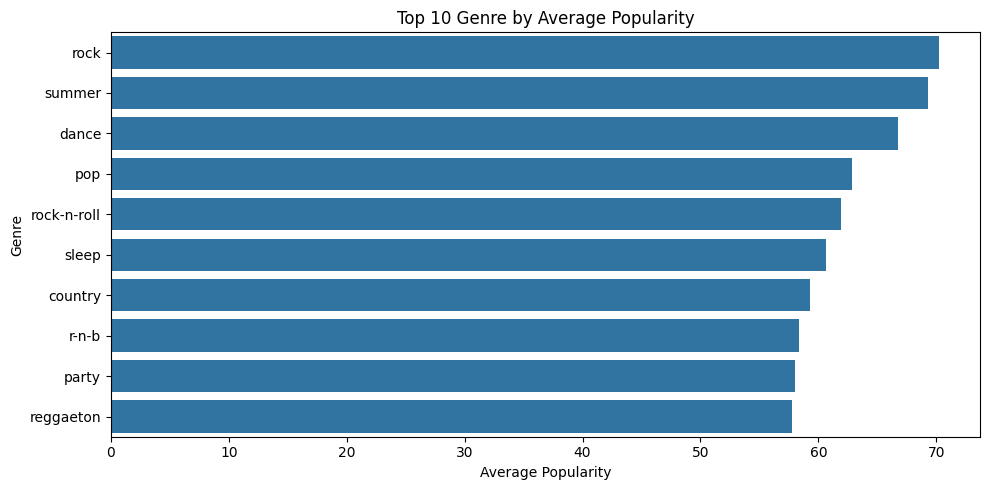

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=result61, x="avg_popularity", y="genre")
plt.title("Top 10 Genre by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


Bagian **Dashboard (Visualisasi)** ini bertujuan untuk menyajikan hasil analisis dalam bentuk grafik agar lebih mudah dipahami. Pada contoh ini digunakan *barplot* untuk menampilkan **Top Genre berdasarkan rata-rata popularitas**.

Grafik menunjukkan perbandingan nilai *average popularity* untuk setiap genre, sehingga memudahkan dalam mengidentifikasi genre mana yang paling populer. Dari visualisasi tersebut terlihat bahwa genre seperti *rock*, *summer*, dan *dance* memiliki rata-rata popularitas tertinggi dibandingkan genre lainnya.

Visualisasi ini membantu dalam menyampaikan insight secara lebih jelas dan intuitif dibandingkan hanya melihat data dalam bentuk tabel.


## **Churn Rate berdasarkan Tipe Subscriber**

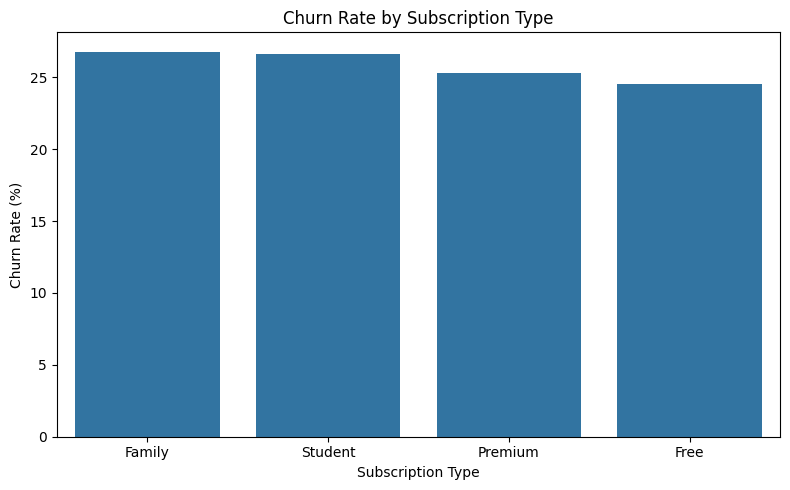

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=result62, x="subscription_type", y="churn_rate_pct")
plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()


Bagian visualisasi ini menampilkan **Churn Rate berdasarkan Subscription Type** dalam bentuk *bar chart*. Grafik ini digunakan untuk membandingkan tingkat churn (persentase pengguna yang berhenti menggunakan layanan) pada setiap jenis langganan.

Dari hasil visualisasi, terlihat bahwa tipe *Family* dan *Student* memiliki churn rate yang sedikit lebih tinggi dibandingkan *Premium* dan *Free*. Hal ini menunjukkan bahwa pengguna pada kategori tersebut cenderung lebih sering berhenti berlangganan. Sementara itu, *Premium* dan *Free* memiliki tingkat churn yang relatif lebih rendah.

Visualisasi ini membantu dalam memahami perilaku pengguna berdasarkan jenis langganan, sehingga dapat menjadi dasar dalam pengambilan keputusan untuk meningkatkan retensi pengguna.

## **Top 10 Listening Behavior berdasarkan Country**

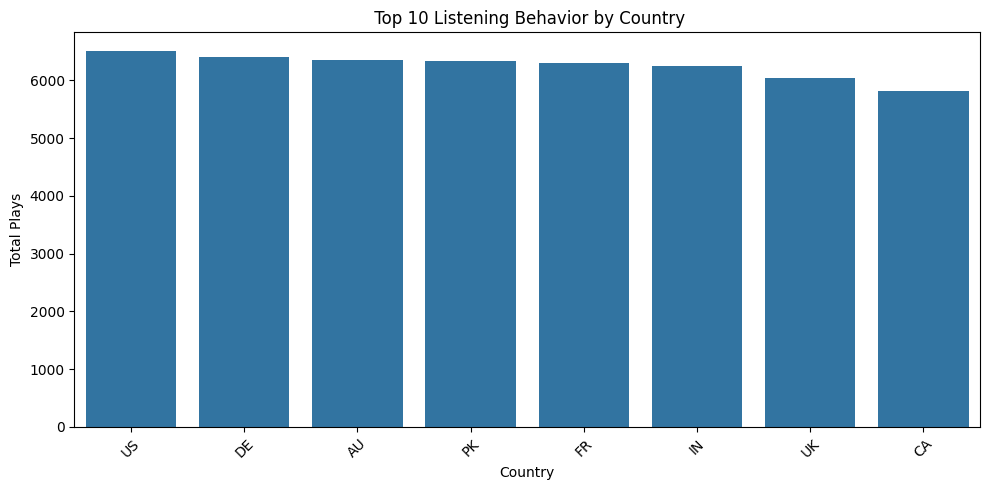

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=result63, x="country", y="total_plays")
plt.title(" Top 10 Listening Behavior by Country")
plt.xlabel("Country")
plt.ylabel("Total Plays")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualisasi ini menampilkan **Listening Behavior berdasarkan Country (Top 10)** dalam bentuk *bar chart*. Grafik ini digunakan untuk membandingkan total jumlah pemutaran lagu (*total plays*) dari berbagai negara dengan aktivitas tertinggi.

Dari grafik terlihat bahwa negara seperti **US, DE, dan AU** memiliki jumlah pemutaran lagu paling tinggi dibandingkan negara lainnya. Perbedaan antar negara tidak terlalu jauh, namun tetap menunjukkan bahwa beberapa negara memiliki tingkat aktivitas mendengarkan musik yang lebih tinggi.

Visualisasi ini membantu dalam memahami distribusi pengguna aktif secara geografis, sehingga dapat menjadi dasar untuk strategi pengembangan pasar atau penyesuaian konten berdasarkan wilayah dengan aktivitas tertinggi.


## **Tren Plays setiap tahun**

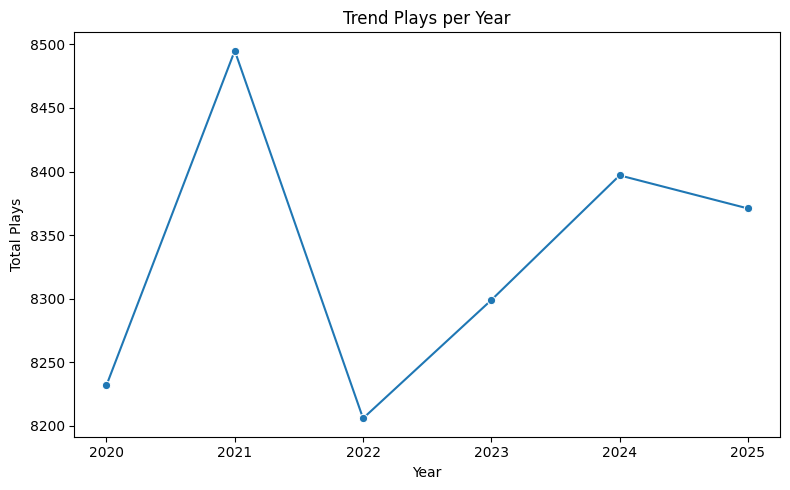

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data=result65, x="year", y="total_plays", marker="o")
plt.title("Trend Plays per Year")
plt.xlabel("Year")
plt.ylabel("Total Plays")
plt.tight_layout()
plt.show()


Visualisasi ini menampilkan **Trend Total Plays per Year** dalam bentuk *line chart*. Grafik ini digunakan untuk melihat perubahan jumlah pemutaran lagu dari tahun ke tahun.

Dari grafik terlihat bahwa jumlah *plays* mengalami fluktuasi, dengan puncak terjadi pada tahun 2021, kemudian mengalami penurunan pada tahun 2022. Setelah itu, tren kembali meningkat pada tahun 2023 dan 2024, meskipun sedikit menurun kembali pada tahun 2025.

Visualisasi ini membantu dalam memahami pola pertumbuhan dan penurunan aktivitas pengguna dari waktu ke waktu, sehingga dapat digunakan untuk mengevaluasi performa platform atau strategi yang telah diterapkan pada periode tertentu.


## **Top Playlist Genre by Age Group**

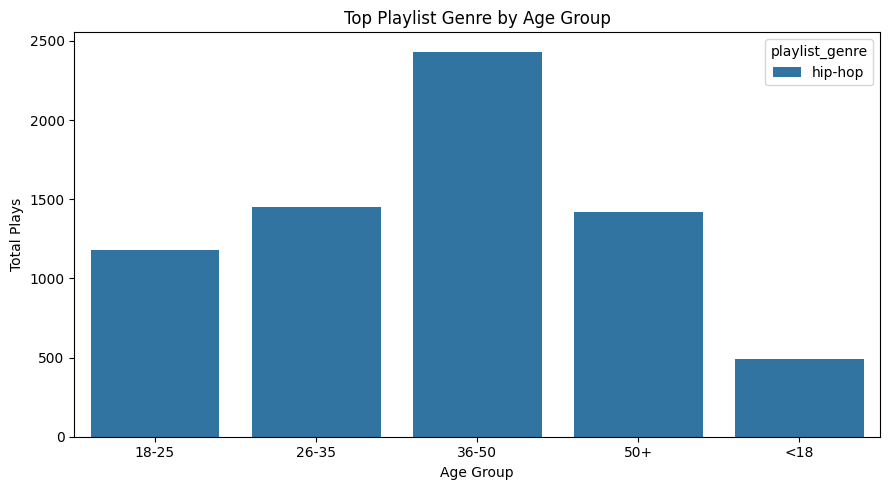

In [ ]:
top_agegroup = (
    result67.sort_values(["age_group", "total_plays"], ascending=[True, False])
    .groupby("age_group")
    .head(1)
    .reset_index(drop=True)
)

plt.figure(figsize=(9,5))
sns.barplot(data=top_agegroup, x="age_group", y="total_plays", hue="playlist_genre")
plt.title("Top Playlist Genre by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Plays")
plt.tight_layout()
plt.show()


## Ringkasan Insight Otomatis


In [ ]:
print("=== RINGKASAN INSIGHT OTOMATIS ===\n")

if len(result61) > 0:
    print(f"1. Genre dengan avg popularity tertinggi: {result61.iloc[0]['genre']}")

if len(result62) > 0:
    print(f"2. Subscription dengan churn rate tertinggi: {result62.iloc[0]['subscription_type']} ({result62.iloc[0]['churn_rate_pct']}%)")

if len(result63) > 0:
    print(f"3. Country dengan total plays tertinggi: {result63.iloc[0]['country']} ({result63.iloc[0]['total_plays']})")

if len(result64) > 0:
    best_skip = result64.sort_values('avg_skip_rate').iloc[0]
    print(f"4. Popularity level dengan skip rate terendah: {best_skip['popularity_level']} ({best_skip['avg_skip_rate']})")

if len(result66) > 0:
    churn_row = result66[result66['user_status'] == 'Churned']
    if len(churn_row) > 0:
        churn_row = churn_row.iloc[0]
        print(f"5. User churned punya avg skip rate {churn_row['avg_skip_rate']} dan avg listening time {churn_row['avg_listening_time']}")

if len(result67) > 0:
    top_combo = result67.sort_values('total_plays', ascending=False).iloc[0]
    print(f"6. Kombinasi age group & playlist genre teratas: {top_combo['age_group']} - {top_combo['playlist_genre']}")


=== RINGKASAN INSIGHT OTOMATIS ===

1. Genre dengan avg popularity tertinggi: rock
2. Subscription dengan churn rate tertinggi: Family (26.79%)
3. Country dengan total plays tertinggi: US (6507)
4. Popularity level dengan skip rate terendah: Medium (0.2979)
5. User churned punya avg skip rate 0.3013 dan avg listening time 198.52
6. Kombinasi age group & playlist genre teratas: 36-50 - hip-hop


# Kesimpulan

Berdasarkan proses ETL dan analisis Data Warehouse:
1. Tiga dataset Spotify berhasil diintegrasikan menjadi model **star schema**.
2. Transformasi data membuat struktur lebih konsisten dan siap dianalisis.
3. Data Warehouse berhasil disimpan dalam **SQLite (`spotify_dw.db`)**.
4. Analisis OLAP menunjukkan insight terkait:
   - genre paling populer,
   - churn berdasarkan subscription,
   - perilaku user berdasarkan negara,
   - hubungan audio features dengan skip rate,
   - tren plays berdasarkan waktu,
   - perbedaan user aktif vs churned,
   - preferensi playlist berdasarkan kelompok umur.
5. Dashboard membantu menyajikan hasil analisis secara lebih visual dan mudah dipahami.


## Menutup Koneksi Database


In [ ]:
print("Notebook selesai dijalankan. Database utama berada di:")
print(DB_PATH)


Notebook selesai dijalankan. Database utama berada di:
/content/drive/MyDrive/dataset BIawak/spotify_dw.db
